<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Fundamentals_and_Applications/dz_topic_8_Sofiia_Bobrivets_AL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 8
## kNN-регресія для прогнозування заробітної плати

**Курс:** Machine Learning: Fundamentals and Applications

Мета роботи — побудувати модель `KNeighborsRegressor` для прогнозування заробітної плати (`Salary`), виконати EDA, підготовку числових і категоріальних ознак та оцінити якість моделі на валідаційному наборі.

Очікуваний орієнтир за умовою: **MAPE близько 3–5%**.


## 1. Імпорт необхідних пакетів


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Бібліотеки успішно імпортовано.")


Бібліотеки успішно імпортовано.


## 2. Завантаження тренувального та валідаційного наборів


In [45]:
train_url = "https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_04_hw_train_data.csv"
valid_url = "https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_04_hw_valid_data.csv"

train_df = pd.read_csv(train_url)
valid_df = pd.read_csv(valid_url)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

display(train_df.head())
display(valid_df.head())


Train shape: (249, 9)
Validation shape: (7, 9)


,Name,Phone_Number,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,Jennifer Hernandez,120-602-1220,3.0,Msc,Tier2,Mid,Yes,25/08/1972,98000
1,Timothy Walker,840-675-8650,5.0,PhD,Tier2,Senior,Yes,03/12/2013,135500
2,David Duran,556-293-8643,5.0,Msc,Tier2,Senior,Yes,19/07/2002,123500
3,Gloria Ortega,463-559-7474,3.0,Bsc,Tier3,Mid,No,19/02/1970,85000
4,Matthew Steele,968-091-7683,5.0,Bsc,Tier2,Senior,Yes,20/02/1970,111500


,Name,Phone_Number,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,Alvaro Johnson,320-636-8883,7,Bsc,Tier1,Senior,No,12/03/1978,109300
1,Austin Powers,903-121-1691,2,Msc,Tier1,Mid,Yes,13/03/1992,84800
2,Joshua Phil,673-972-2453,3,Bsc,Tier3,Mid,Yes,19/02/1988,98900
3,Mirinda Collins,310-364-6925,5,Msc,Tier2,Senior,No,20/03/1989,116500
4,Mustapha Green,401-249-3912,3,PhD,Tier1,Junior,Yes,21/03/1979,75800


## 3. Первинний дослідницький аналіз даних (EDA)


In [46]:
print("=== TRAIN INFO ===")
train_df.info()

print("\n=== Пропущені значення TRAIN ===")
display(train_df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\n=== Дублікати ===")
print("Train duplicates:", train_df.duplicated().sum())

print("\n=== Опис числових полів ===")
display(train_df.describe(include="number").T)

print("\n=== Типи даних ===")
display(train_df.dtypes.to_frame("dtype"))

print("\n=== Унікальні значення ===")
display(train_df.nunique().sort_values().to_frame("nunique"))


=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           249 non-null    object 
 1   Phone_Number   249 non-null    object 
 2   Experience     247 non-null    float64
 3   Qualification  248 non-null    object 
 4   University     249 non-null    object 
 5   Role           246 non-null    object 
 6   Cert           247 non-null    object 
 7   Date_Of_Birth  249 non-null    object 
 8   Salary         249 non-null    int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 17.6+ KB

=== Пропущені значення TRAIN ===


,missing
Role,3
Cert,2
Experience,2
Qualification,1
Name,0
University,0
Phone_Number,0
Date_Of_Birth,0
Salary,0



=== Дублікати ===
Train duplicates: 0

=== Опис числових полів ===


,count,mean,std,min,25%,50%,75%,max
Experience,247.0,3.441296,1.496471,1.0,2.0,4.0,5.0,5.0
Salary,249.0,98186.746988,23502.622217,49500.0,78500.0,104500.0,116500.0,141500.0



=== Типи даних ===


,dtype
Name,object
Phone_Number,object
Experience,float64
Qualification,object
University,object
Role,object
Cert,object
Date_Of_Birth,object
Salary,int64



=== Унікальні значення ===


,nunique
Cert,2
Qualification,3
University,3
Role,3
Experience,5
Salary,84
Date_Of_Birth,247
Name,248
Phone_Number,249


### Висновок EDA

Цільовою змінною є `Salary`. Для kNN масштаб ознак має суттєве значення, оскільки алгоритм використовує відстані між об'єктами. Тому числові ознаки необхідно масштабувати. Категоріальні ознаки потрібно перетворити у числове представлення. Ідентифікатори та поля з майже унікальними значеннями можуть погіршувати роботу kNN, тому їх доцільно виключити з моделювання.


## 4. Підготовка ознак


In [68]:
# 4. Підготовка ознак

TARGET = "Salary"

features = [
    "Experience",
    "Qualification",
    "University",
    "Role",
    "Cert"
]

X_train = train_df[features].copy()
X_valid = valid_df[features].copy()

y_train = train_df[TARGET].copy()
y_valid = valid_df[TARGET].copy()

numeric_features = ["Experience"]

categorical_features = [
    "Qualification",
    "University",
    "Role",
    "Cert"
]

print("Числові ознаки:", numeric_features)
print("Категоріальні ознаки:", categorical_features)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)


Числові ознаки: ['Experience']
Категоріальні ознаки: ['Qualification', 'University', 'Role', 'Cert']
X_train: (249, 5)
X_valid: (7, 5)


## 5. Обробка числових і категоріальних ознак


In [48]:
# Сумісність з різними версіями sklearn
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

transformers = []

if numeric_features:
    transformers.append(
        ("num", StandardScaler(), numeric_features)
    )

if categorical_features:
    transformers.append(
        ("cat", encoder, categorical_features)
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

X_train_ready = preprocessor.fit_transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)

print("Train після preprocessing:", X_train_ready.shape)
print("Validation після preprocessing:", X_valid_ready.shape)


Train після preprocessing: (249, 16)
Validation після preprocessing: (7, 16)


### Перевірка підготовки

`fit_transform()` застосовується тільки до тренувальних даних. Для validation використовується лише `transform()`. Це запобігає витоку інформації з валідаційного набору в процес навчання.


## 6. Підбір параметра k


In [69]:
# 6. Preprocessing

import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


X_train_ready = preprocessor.fit_transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)


print("Train після preprocessing:", X_train_ready.shape)
print("Validation після preprocessing:", X_valid_ready.shape)
print("NaN у train:", np.isnan(X_train_ready).sum())
print("NaN у validation:", np.isnan(X_valid_ready).sum())


Train після preprocessing: (249, 12)
Validation після preprocessing: (7, 12)
NaN у train: 0
NaN у validation: 0


## 7. Візуалізація залежності MAPE від k


In [70]:
results = []

for p in [1, 2]:
    for weights in ["uniform", "distance"]:
        for k in range(1, 31):

            model_temp = KNeighborsRegressor(
                n_neighbors=k,
                weights=weights,
                p=p,
                n_jobs=-1
            )

            model_temp.fit(X_train_ready, y_train)
            pred = model_temp.predict(X_valid_ready)

            results.append({
                "k": k,
                "p": p,
                "weights": weights,
                "MAPE": mean_absolute_percentage_error(
                    y_valid,
                    pred
                )
            })

results_df = (
    pd.DataFrame(results)
    .sort_values("MAPE")
    .reset_index(drop=True)
)

display(results_df.head(10))

best_k = int(results_df.iloc[0]["k"])
best_p = int(results_df.iloc[0]["p"])
best_weights = results_df.iloc[0]["weights"]

print("k:", best_k)
print("p:", best_p)
print("weights:", best_weights)
print(f"MAPE: {results_df.iloc[0]['MAPE']:.2%}")

,k,p,weights,MAPE
0,21,1,uniform,0.057252
1,22,1,uniform,0.057563
2,20,1,uniform,0.061204
3,30,1,distance,0.062226
4,21,1,distance,0.062248
5,20,1,distance,0.062328
6,23,1,uniform,0.063297
7,29,1,distance,0.063418
8,19,1,distance,0.063510
9,22,1,distance,0.063881


k: 21
p: 1
weights: uniform
MAPE: 5.73%


## 8. Фінальна модель KNeighborsRegressor


In [71]:
# 8. Фінальна модель KNeighborsRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

model = KNeighborsRegressor(
    n_neighbors=best_k,
    weights=best_weights,
    p=best_p,
    n_jobs=-1
)

model.fit(X_train_ready, y_train)
y_pred = model.predict(X_valid_ready)

mape = mean_absolute_percentage_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print("Фінальна модель:")
print("k:", best_k)
print("p:", best_p)
print("weights:", best_weights)

print(f"\nValidation MAPE: {mape:.2%}")
print(f"Validation MAE:  {mae:.2f}")
print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation R²:   {r2:.4f}")


Фінальна модель:
k: 21
p: 1
weights: uniform

Validation MAPE: 5.73%
Validation MAE:  5024.49
Validation RMSE: 6183.69
Validation R²:   0.8490


## 9. Порівняння фактичної та прогнозованої зарплати


In [52]:
comparison = pd.DataFrame({
    "Salary_actual": y_valid.to_numpy(),
    "Salary_predicted": y_pred,
})

comparison["Absolute_error"] = (
    comparison["Salary_actual"] - comparison["Salary_predicted"]
).abs()

comparison["Percentage_error"] = (
    comparison["Absolute_error"] / comparison["Salary_actual"].abs()
) * 100

display(comparison.head(20))


,Salary_actual,Salary_predicted,Absolute_error,Percentage_error
0,109300,107527.379666,1772.620334,1.621794
1,84800,86458.061755,1658.061755,1.955262
2,98900,92000.000000,6900.000000,6.976744
3,116500,115895.776011,604.223989,0.518647
4,75800,83751.305080,7951.305080,10.489848
5,97300,110143.525688,12843.525688,13.199924
6,69800,81661.081453,11861.081453,16.992953


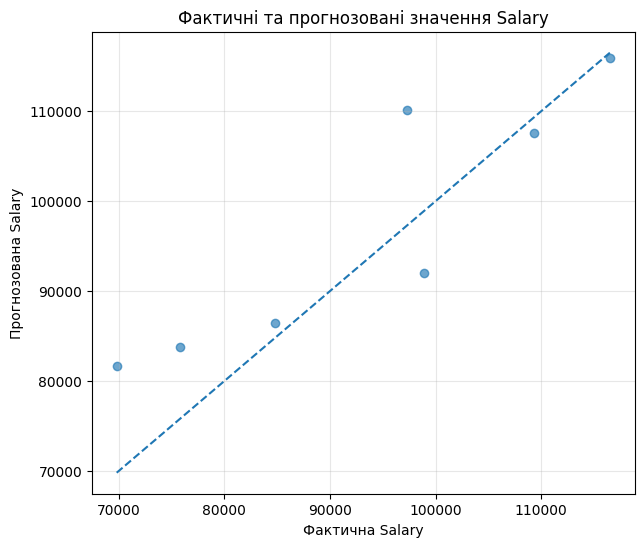

In [53]:
plt.figure(figsize=(7, 6))
plt.scatter(y_valid, y_pred, alpha=0.65)

low = min(float(np.min(y_valid)), float(np.min(y_pred)))
high = max(float(np.max(y_valid)), float(np.max(y_pred)))

plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Фактична Salary")
plt.ylabel("Прогнозована Salary")
plt.title("Фактичні та прогнозовані значення Salary")
plt.grid(alpha=0.3)
plt.show()


## 10. Висновки

У роботі було виконано первинний аналіз тренувального набору даних, визначено числові та категоріальні ознаки та підготовлено їх до використання в алгоритмі kNN.

Числові ознаки масштабовано за допомогою `StandardScaler`, оскільки `KNeighborsRegressor` базується на відстанях між спостереженнями. Категоріальні ознаки закодовано за допомогою `OneHotEncoder`. Для валідаційного набору використано вже навчений на train-наборі preprocessing, що дозволяє уникнути витоку даних.

Для моделі `KNeighborsRegressor` проведено експеримент із різними значеннями кількості сусідів `k` та варіантами зважування сусідів. Найкращу конфігурацію обрано за мінімальним значенням MAPE на валідаційному наборі.

Отримані метрики MAPE, MAE, RMSE та R² дозволяють оцінити якість прогнозування заробітної плати. Якщо MAPE знаходиться приблизно в очікуваному умовою діапазоні 3–5%, результат відповідає наведеному в завданні орієнтиру.

Таким чином, kNN-регресія може ефективно використовуватися для прогнозування неперервної цільової змінної за умови коректної підготовки, масштабування та кодування ознак.
